# Studying the Attention
## ===========================
### In this notebook, we will study the attention mechanism in both GAT and transformer model.

In [2]:
# Import necessary libraries
import argparse
import os.path as osp
from typing import Any, Dict, Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch_geometric.data import InMemoryDataset, Data
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch_geometric.transforms as T
from torch.nn import BatchNorm1d, Embedding, Linear, ModuleList, ReLU, Sequential
from torch_geometric.datasets import ZINC
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, GPSConv, global_add_pool
from torch_geometric.nn.attention import PerformerAttention

In [3]:
# Create dataset for edge regression
class CremonaDataset(InMemoryDataset):
    def __init__(self, edge_index, x, y, pre_transform = None , transform=None):
        super(CremonaDataset, self).__init__('.', transform, None, None)
        
        # Create data object
        data = Data(x=torch.FloatTensor(x), 
                   y=torch.FloatTensor(y), 
                   edge_index=edge_index)
        
        # Set number of nodes and features
        data.num_nodes = x.shape[0]
        data.num_features = x.shape[1]
        data.num_edges = edge_index.shape[1]
        
        # Split data into train/val/test sets (70%/15%/15%)
        np.random.seed(0)
        n_nodes = data.num_nodes
        n_edges = data.num_edges
        indices = np.random.permutation(n_edges)
        #print(n_nodes) #debug
        
        train_idx = indices[:int(0.7 * n_edges)]
        #print(len(train_idx)) #debug
        val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
        test_idx = indices[int(0.85 * n_edges):]
        
        # Create masks
        train_mask = torch.zeros(n_edges, dtype=torch.bool)
        val_mask = torch.zeros(n_edges, dtype=torch.bool)
        test_mask = torch.zeros(n_edges, dtype=torch.bool)
        
        train_mask[train_idx] = True
        val_mask[val_idx] = True
        test_mask[test_idx] = True
        
        data.train_mask = train_mask    #size is still all nodes but only True for train nodes
        data.val_mask = val_mask
        data.test_mask = test_mask
        
        self.data, self.slices = self.collate([data])
        
        print("Dataset created with {} nodes".format(data.num_nodes), "and {} edges".format(edge_index.shape[1]))

In [4]:
# Load data
edges_gnn = gpd.read_file('edges_PC.geojson')
nodes_gnn = gpd.read_file('nodes_PC.geojson')

# Preprocess node features
X = nodes_gnn.drop(columns=['geometry', 'railway', 'highway']).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
Y = edges_gnn['traffic_speed'].values
Y = np.array(Y)


# Prepare edge index 
node_to_id = {}
for i, node in enumerate(nodes_gnn['osmid'].values):
    node_to_id[node] = i

start_node = [node_to_id[i] for i in edges_gnn['u'].values]
end_node = [node_to_id[i] for i in edges_gnn['v'].values]
start = torch.tensor(start_node, dtype=torch.long)
end = torch.tensor(end_node, dtype=torch.long)
edge_index = torch.stack([start, end], dim=0)

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

dataset = CremonaDataset(edge_index, X_scaled, Y)
data = dataset[0].to(device)

cpu
Dataset created with 3231 nodes and 6930 edges


## Let's start with the GAT model

I added a quick debugging before looking into the attention weights so that we can see that without any kind of pooling the number of nodes/edges in the graph is preserved.
What changes is how the feature of EACH node is represented.

In [67]:
#debugging of GATv2Conv
print("Edge index shape:", data.edge_index.shape)
print("X shape:", data.x.shape)
print("Y shape:", data.y.shape)
print("Train mask shape:", data.train_mask.shape)
print("Val mask shape:", data.val_mask.shape)
print("Test mask shape:", data.test_mask.shape)
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)

# Define the GATv2 model
class GATv2(nn.Module):
    def __init__(self, in_channels, out_channels, heads=4):
        super(GATv2, self).__init__()
        self.gat1 = GATv2Conv(in_channels, out_channels, heads=heads)
        self.gat2 = GATv2Conv(out_channels * heads, out_channels, heads=1)
        self.linear = nn.Linear(out_channels * 2, 1)
        
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        print("X shape:", x.shape)
        print("Edge index shape:", edge_index.shape)
        x = F.elu(self.gat1(x, edge_index))
        print("X shape after conv1:", x.shape)
        x = F.elu(self.gat2(x, edge_index))
        print("X shape after conv2:", x.shape)

        src, dst = edge_index 
        x = torch.concat((x[src], x[dst]), dim=-1)
        print("X shape after concat:", x.shape)
        

        x = self.linear(x)
        print("X shape after fc:", x.shape)
        return x
# Initialize model and load trained weights
model = GATv2(out_channels=64, in_channels=X_scaled.shape[1]).to(device)
model.load_state_dict(torch.load('best_CR_gat.pt', map_location=device))



Edge index shape: torch.Size([2, 6930])
X shape: torch.Size([3231, 6])
Y shape: torch.Size([6930])
Train mask shape: torch.Size([6930])
Val mask shape: torch.Size([6930])
Test mask shape: torch.Size([6930])
Number of nodes: 3231
Number of edges: 6930


<All keys matched successfully>

In [68]:
# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression

# Training function
def train():
    model.train()
    optimizer.zero_grad()
    # Forward pass
    out = model(data)
    # Compute loss (only on training nodes)
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask]) # squeeze() to remove extra dimension
    # Backward pass
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()
test_loss = evaluate(data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

X shape: torch.Size([3231, 6])
Edge index shape: torch.Size([2, 6930])
X shape after conv1: torch.Size([3231, 256])
X shape after conv2: torch.Size([3231, 64])
X shape after concat: torch.Size([6930, 128])
X shape after fc: torch.Size([6930, 1])
Final Test Results - Loss: 277.7344


X shape: torch.Size([3231, 6])
Edge index shape: torch.Size([2, 6930])
X shape after conv1: torch.Size([3231, 256])
X shape after conv2: torch.Size([3231, 64])
X shape after concat: torch.Size([6930, 128])
X shape after fc: torch.Size([6930, 1])


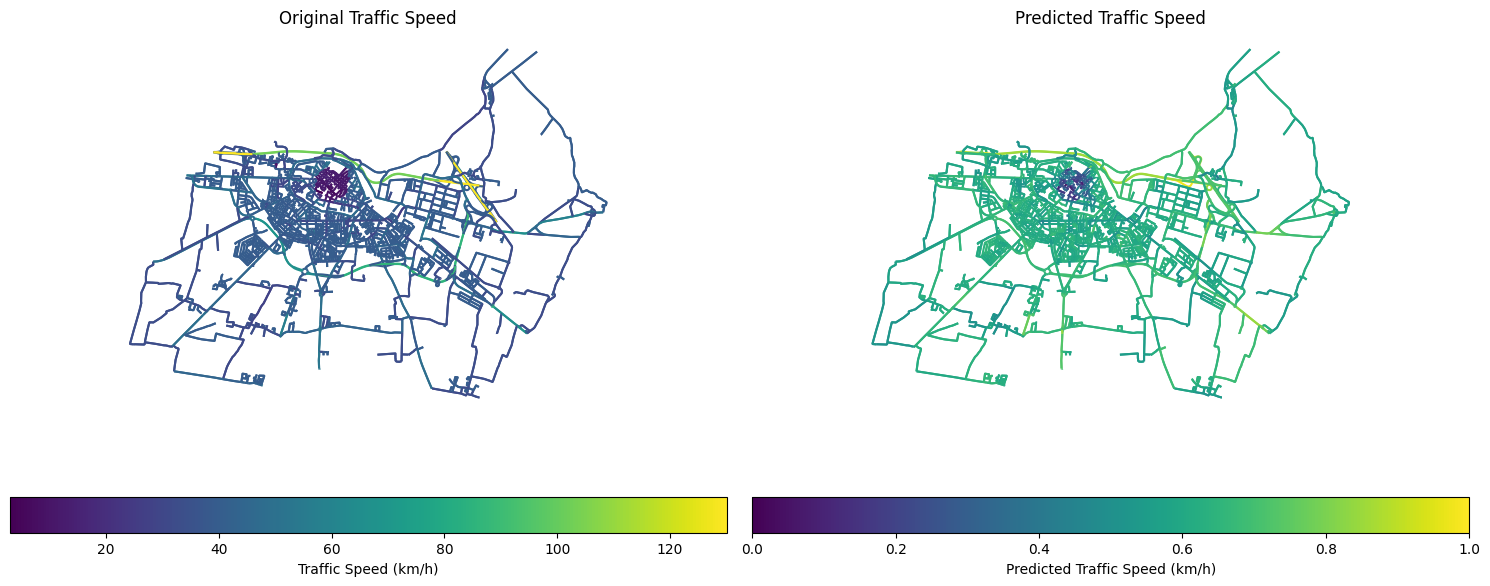

In [69]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data).squeeze().cpu().numpy()

# Normalize the predictions
scaler = MinMaxScaler()
predictions = scaler.fit_transform(predictions.reshape(-1, 1))
    
# Add predictions back to the geodataframe for visualization
edges_gnn['gat_predictions'] = predictions


#Visualize the predictions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()

# Plot the predicted traffic speed
edges_gnn.plot(column='gat_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()

plt.tight_layout()
plt.show()

In [7]:

# Define GAT model with attention inspection
class GATv2(nn.Module):
    def __init__(self, hidden_dim, num_features, heads=4):
        super().__init__()
        self.gat1 = GATv2Conv(num_features, hidden_dim, heads=heads)
        self.gat2 = GATv2Conv(hidden_dim*heads, hidden_dim, heads=1)
        self.linear = nn.Linear(hidden_dim*2, 1)

    def forward_attention(self, x, edge_index):
        x, (edge_index1, attn1) = self.gat1(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        x, (edge_index2, attn2) = self.gat2(x, edge_index, return_attention_weights=True)
        return (edge_index1, attn1), (edge_index2, attn2)

# Initialize model and load trained weights
model = GATv2(hidden_dim=64, num_features=X_scaled.shape[1]).to(device)
model.load_state_dict(torch.load('best_CR_gat.pt', map_location=device))

# Get attention weights
with torch.no_grad():
    (edge_index1, attn1), (edge_index2, attn2) = model.forward_attention(
        torch.FloatTensor(X_scaled).to(device),
        edge_index.to(device)
    )

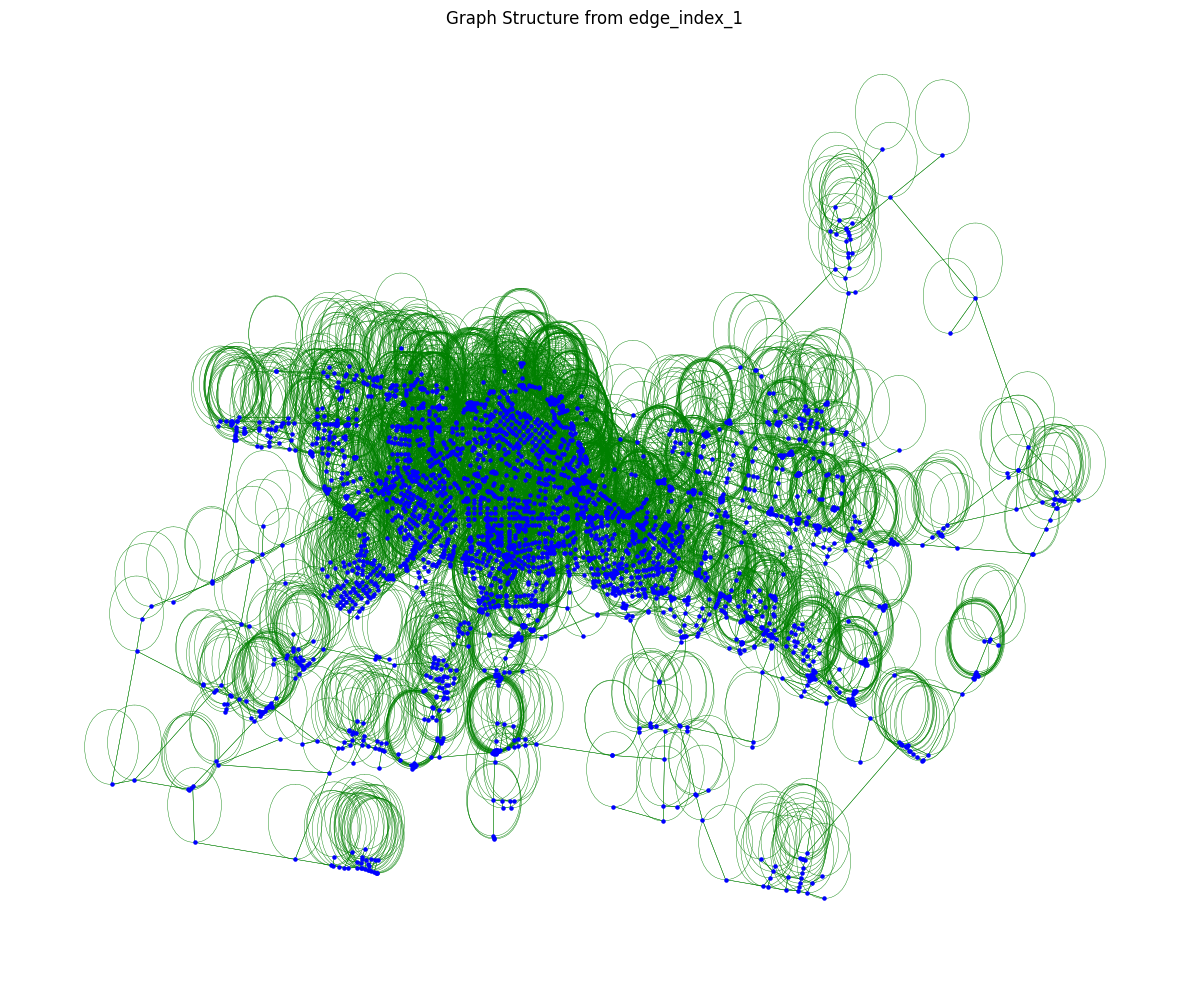

In [8]:
import networkx as nx

import matplotlib.pyplot as plt

# Create a directed graph from edge_index1
G = nx.DiGraph()
edges = [(edge_index1[0, i].item(), edge_index1[1, i].item()) for i in range(edge_index1.shape[1])]
G.add_edges_from(edges)

# Get positions for nodes using the geometry from nodes_gnn
pos = {i: (row.geometry.x, row.geometry.y) for i, row in nodes_gnn.iterrows()}

# Create figure
plt.figure(figsize=(12, 10))

# Plot the network
nx.draw_networkx(G, pos, 
                 node_size=5,
                 node_color='blue',
                 edge_color='green',
                 width=0.3,
                 arrows=False,
                 with_labels=False)

plt.title('Graph Structure from edge_index_1')
plt.axis('off')
plt.tight_layout()
plt.show()

IMPORTANT STAFF: ATTENTION WEIGHTS ARE: NUMBER EDGES (importance of each neighborhood) + NUMBER NODES (importance of the node itself) - SELF LOOPS (not counting node themself twice), this is in order to not count the self loops twice.
KEEP GOING FROM HERE

### Let's study a given node and its neighbors
Informations flow from source to target along the edges, neighbors that have a role in computing the attention are only those that "flow" into a given node.

In [9]:
# find the node with the most neighbors
degree_dict = dict(G.degree())
max_degree_node = max(degree_dict, key=degree_dict.get)
max_degree = degree_dict[max_degree_node]
print(f"Node with most neighbors: {max_degree_node} with degree {max_degree}")

Node with most neighbors: 342 with degree 10


In [10]:
import seaborn as sns
# Study only one node
node_id = 999
# find nodes that point to node_id
target_mask = edge_index2[1] == node_id
neighbors = edge_index2[0][target_mask].cpu().detach().numpy()

print(f"Node {node_id} has {len(neighbors)} neighbors")
print(f"Neighbors: {neighbors}")

# Get the attention weights for the edges pointing to node_id
attention_weights = attn2[target_mask].cpu().detach().numpy()
attention_weights1 = attention_weights[:, 0]  # Select only one head
#attention_weights2 = attention_weights[:, 1]  # Select only one head
print(f"Attention weights for edges pointing to node {node_id}: {attention_weights}")
print(f"Total attention weight: {np.sum(attention_weights)}") #2 heads so should be 2

Node 999 has 3 neighbors
Neighbors: [435 952 999]
Attention weights for edges pointing to node 999: [[0.00778773]
 [0.0642787 ]
 [0.92793363]]
Total attention weight: 1.0


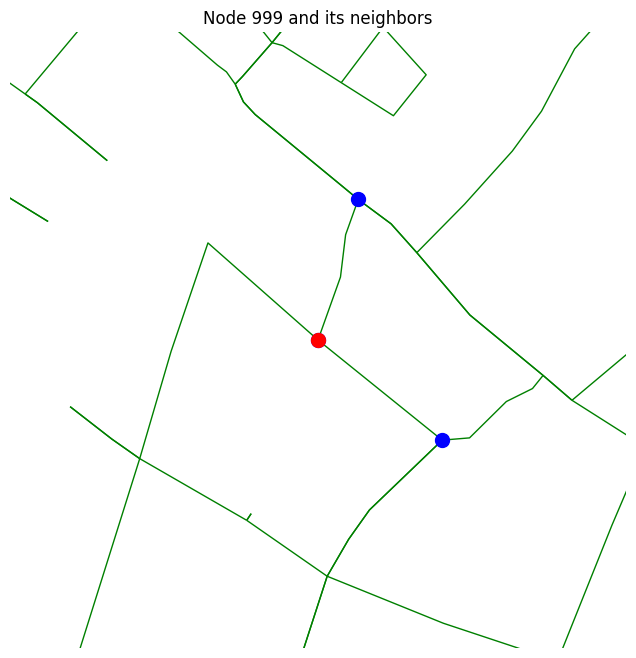

In [11]:
# plot selected node
f, ax = plt.subplots(figsize=(8,8))
ax.scatter(nodes_gnn.x[node_id], nodes_gnn.y[node_id], color='red', s=100, label='Selected Node', zorder=3)
ax.scatter(nodes_gnn.x[neighbors], nodes_gnn.y[neighbors], color='blue', s=100, label='Neighbors', zorder=2)
edges_gnn.plot(ax= ax, linewidth= 1, edgecolor= 'green', zorder=1)

#set xlim and ylim around the selected node
zoom = 200
ax.set_xlim(nodes_gnn.x[node_id] - zoom, nodes_gnn.x[node_id] + zoom)
ax.set_ylim(nodes_gnn.y[node_id] - zoom, nodes_gnn.y[node_id] + zoom)
ax.set_title(f"Node {node_id} and its neighbors")
ax.set_axis_off()

In [12]:
edge_mask = edges_gnn['v'] == nodes_gnn['osmid'][node_id]
edges = edges_gnn[edge_mask]
edges = edges.reset_index(drop=True)
edges['Attention Score1'] = attention_weights1[0:len(edges)]
edges['Attention Score2'] = attention_weights2[0:len(edges)]



#plot 
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8))
edges.plot(ax=ax1, column='Attention Score1', cmap='viridis', legend=True, linewidth=1)
ax1.scatter(nodes_gnn.x[node_id], nodes_gnn.y[node_id], color='red', s=100, label='Selected Node', zorder=3)
ax1.scatter(nodes_gnn.x[neighbors], nodes_gnn.y[neighbors], color='blue', s=100, label='Neighbors', zorder=2)
ax1.set_title('Attention Score1')
ax1.set_axis_off()
'''
edges.plot(ax=ax2, column='Attention Score2', cmap='viridis', legend=True, linewidth=1)
ax2.scatter(nodes_gnn.x[node_id], nodes_gnn.y[node_id], color='red', s=100, label='Selected Node', zorder=3)
ax2.scatter(nodes_gnn.x[neighbors], nodes_gnn.y[neighbors], color='blue', s=100, label='Neighbors', zorder=2)
ax2.set_title('Attention Score2')
ax2.set_axis_off()
'''


NameError: name 'attention_weights2' is not defined

An idea could be that since the "traffic speed" is computed considering the betwenness centrality of a node, then the attention weights are computed considering if a neighbor has to "flow" into the given node or not.

### Showing most important neighbors
I want to highlight only the high attention connections, in order to see if there are patterns in the attention weights.
1. Select a threshold
2. Select the edges that are above the threshold


In [13]:
# Threshold attention weights
threshold = 0.5
mask = attn1[:,0] > threshold
# Get the edges that have attention weights above the threshold
filtered_att = attn1[mask]

# Get the indices of the edges that have attention weights above the threshold
indices = torch.nonzero(mask, as_tuple=True)[0]
# Get the edges that have attention weights above the threshold
filtered_edges = edge_index1[:, indices]
filtered_edges = filtered_edges.cpu().detach().numpy()


filtered_att_1 = filtered_att[:,0].cpu().detach().numpy()
filtered_att_2 = filtered_att[:,1].cpu().detach().numpy()
filtered_att_3 = filtered_att[:,2].cpu().detach().numpy()
filtered_att_4 = filtered_att[:,3].cpu().detach().numpy()

In [14]:
# node index to osmid
filtered_edges_osmid = []
for i in range(filtered_edges.shape[1]):
    filtered_edges_osmid.append([nodes_gnn['osmid'][filtered_edges[0][i]], nodes_gnn['osmid'][filtered_edges[1][i]]])

filtered_edges_osmid = pd.DataFrame(filtered_edges_osmid, columns=['u', 'v'])
filtered_edges_osmid.shape
filtered_edges_osmid['Attention Score 1'] = filtered_att_1
filtered_edges_osmid['Attention Score 2'] = filtered_att_2
filtered_edges_osmid['Attention Score 3'] = filtered_att_3
filtered_edges_osmid['Attention Score 4'] = filtered_att_4
filtered_edges_osmid.head(10)

,u,v,Attention Score 1,Attention Score 2,Attention Score 3,Attention Score 4
0,92972680,298033861,0.996696,0.009115,0.000944,0.920994
1,298033861,462186975,0.659116,0.363219,0.306282,0.609890
2,298033861,92975229,0.584316,0.157796,0.087437,0.425419
3,92975190,291008924,0.513544,0.015157,0.417591,0.532064
4,262013618,262013627,0.530289,0.299988,0.567200,0.212726
5,262013618,4210378533,0.572799,0.088797,0.091516,0.525400
6,4210378533,4511978847,0.665170,0.198986,0.476280,0.371436
7,485233412,485233433,0.504184,0.495550,0.494807,0.500953
8,904993052,262120585,0.508367,0.224381,0.083510,0.530038
9,485192095,485192096,0.501162,0.499568,0.499647,0.501842


In [15]:
# self attention, find the self loops
self_loops = []
for i in range(filtered_edges.shape[1]):
    if filtered_edges[0][i] == filtered_edges[1][i]:
        self_loops.append(filtered_edges_osmid.iloc[i])
self_loops = pd.DataFrame(self_loops, columns=['u', 'v'])
self_loops.shape

filtered_edges_osmid = filtered_edges_osmid[~filtered_edges_osmid.isin(self_loops)].dropna()


In [16]:
#plot the nodes connected by the filtered edges
nodes = set(filtered_edges[0].tolist() + filtered_edges[1].tolist())

# Select nodes_gnn corresponding to nodes
nodes_gnn_filtered = nodes_gnn[nodes_gnn.index.isin(nodes)]
print(f"Number of filtered nodes: {len(nodes_gnn_filtered)}")

#find the edges by matching the u and v columns in edges_gnn with filtered_edges
edges_gnn_filtered = edges_gnn.merge(filtered_edges_osmid, on=['u', 'v'], how='inner')
print(f"Number of filtered edges: {len(edges_gnn_filtered)}")


# assign attention weights to the filtered edges
edges_gnn_filtered['Attention Score 1'] = filtered_edges_osmid['Attention Score 1']
edges_gnn_filtered['Attention Score 2'] = filtered_edges_osmid['Attention Score 2']
edges_gnn_filtered['Attention Score 3'] = filtered_edges_osmid['Attention Score 3']
edges_gnn_filtered['Attention Score 4'] = filtered_edges_osmid['Attention Score 4']

Number of filtered nodes: 2399
Number of filtered edges: 1293


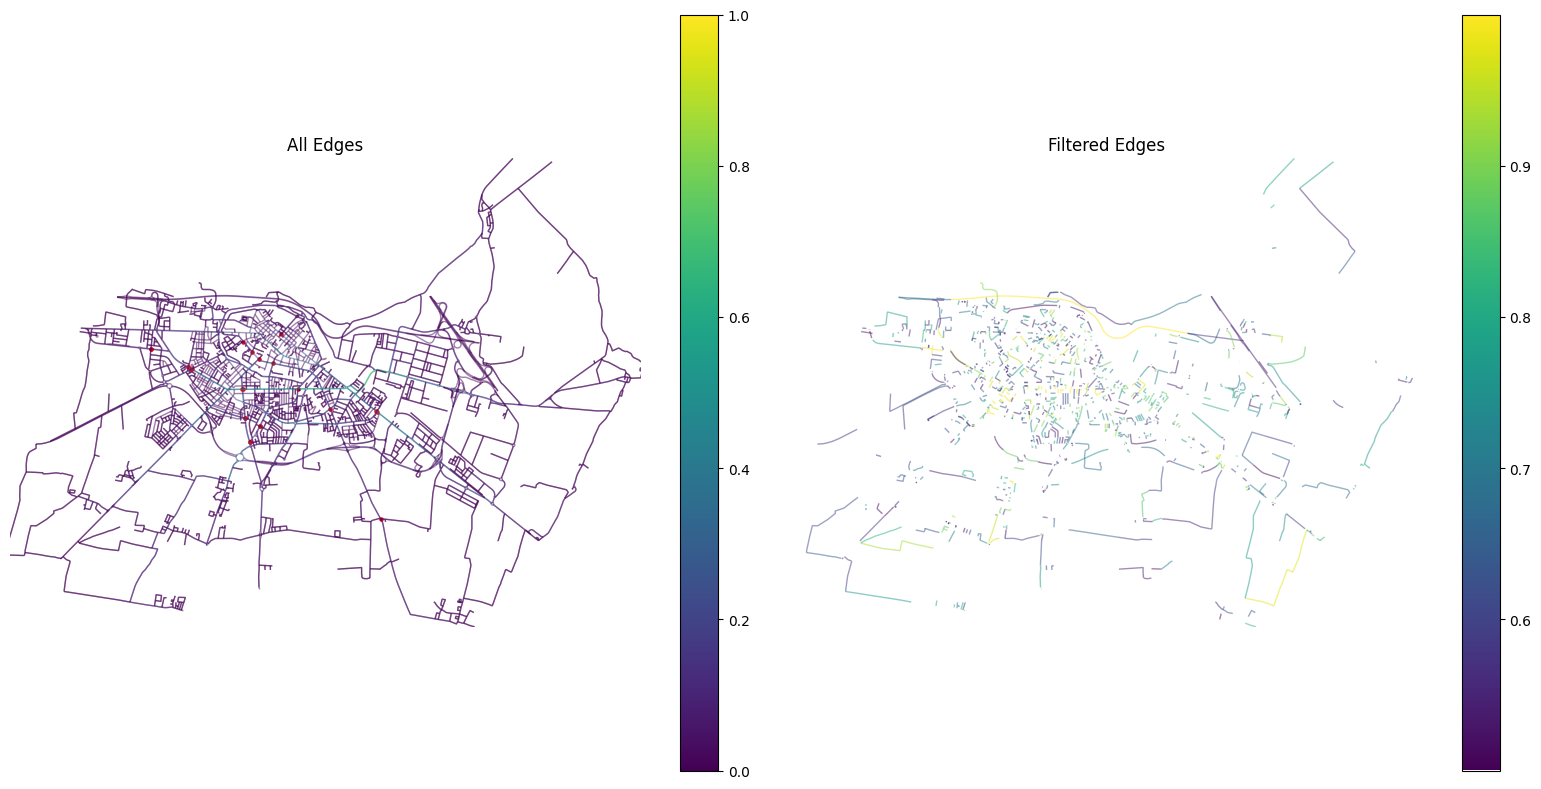

In [17]:
# Visualization of filtered edges vs all edges
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot all edges
edges_gnn.plot(ax=ax1, linewidth=1, alpha=0.5, column = 'edge_bc', cmap='viridis', legend=True)
nodes_gnn[nodes_gnn['traffic_lights'] == 1].plot(ax=ax1, color='red', markersize=5)
ax1.set_title('All Edges')
ax1.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax1.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax1.set_axis_off()

# Plot filtered edges
edges_gnn_filtered.plot(ax=ax2, linewidth=1, alpha=0.5, column='Attention Score 1', cmap='viridis', legend=True)
#nodes_gnn.plot(ax=ax2, color='blue', markersize=2)
ax2.set_title('Filtered Edges')
ax2.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax2.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax2.set_axis_off()
plt.tight_layout()
plt.show()

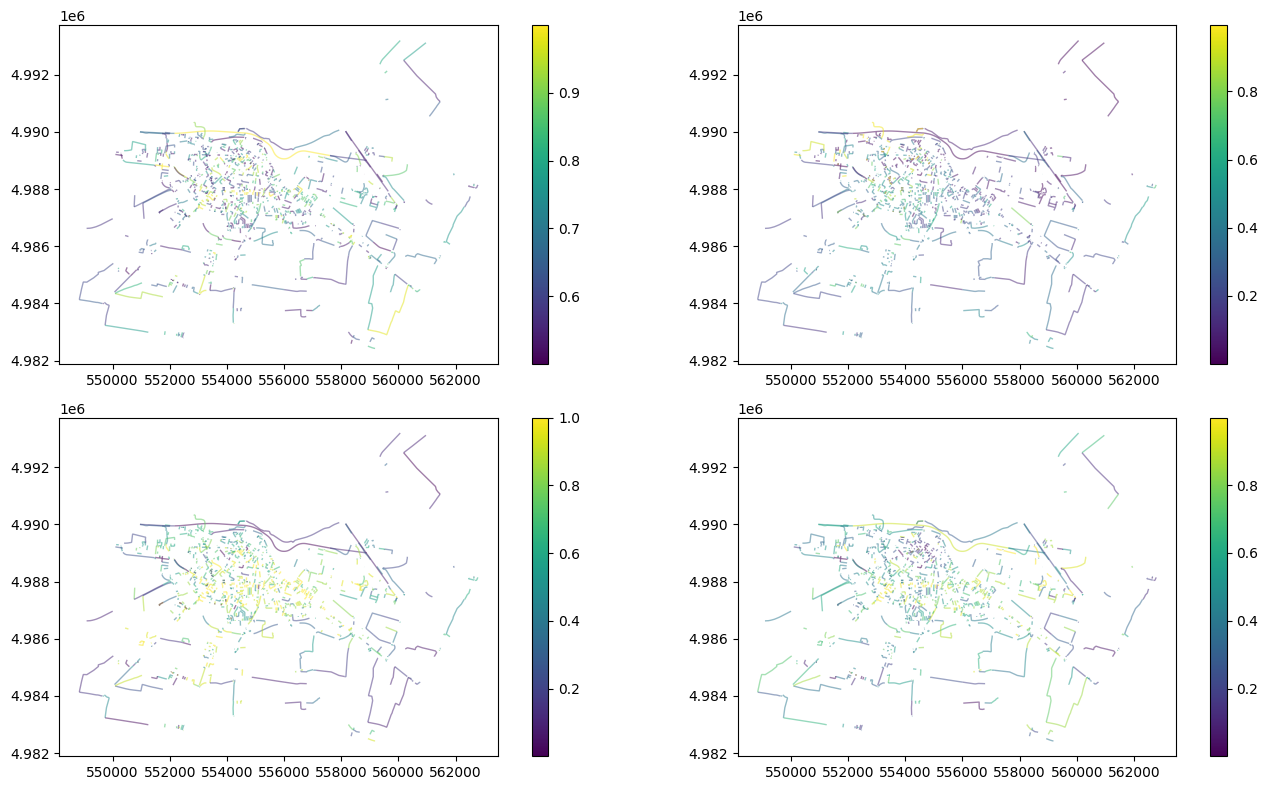

In [18]:
# plot all 4 attention heads scores
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
ax1, ax2, ax3, ax4 = axs.flatten()
edges_gnn_filtered.plot(ax=ax1, linewidth=1, alpha=0.5, column='Attention Score 1', cmap='viridis', legend=True)

edges_gnn_filtered.plot(ax=ax2, linewidth=1, alpha=0.5, column='Attention Score 2', cmap='viridis', legend=True)

edges_gnn_filtered.plot(ax=ax3, linewidth=1, alpha=0.5, column='Attention Score 3', cmap='viridis', legend=True)

edges_gnn_filtered.plot(ax=ax4, linewidth=1, alpha=0.5, column='Attention Score 4', cmap='viridis', legend=True)

plt.tight_layout()
plt.show()


High similarity between 1-4 and 2-3

### Inspect the second layer, first layer was one hop, second layer is two hops


In [19]:
attn2.shape

torch.Size([10133, 1])

In [20]:
# threshold attention weights
threshold = 0.5
mask = attn2 > threshold
# Get the edges that have attention weights above the threshold
filtered_att = attn2[mask]
# Get the indices of the edges that have attention weights above the threshold
indices = torch.nonzero(mask, as_tuple=True)[0]
# Get the edges that have attention weights above the threshold
filtered_edges = edge_index2[:, indices]
filtered_edges = filtered_edges.cpu().detach().numpy()


In [21]:
# translate node index to osmid
filtered_edges_osmid = []
for i in range(filtered_edges.shape[1]):
    filtered_edges_osmid.append([nodes_gnn['osmid'][filtered_edges[0][i]], nodes_gnn['osmid'][filtered_edges[1][i]]])
filtered_edges_osmid = pd.DataFrame(filtered_edges_osmid, columns=['u', 'v'])
filtered_edges_osmid.shape
filtered_edges_osmid['Attention Score'] = filtered_att.cpu().detach().numpy()
print(f"Number of filtered edges: {len(filtered_edges_osmid)}")
# self attention, find the self loops
self_loops = []
for i in range(filtered_edges.shape[1]):
    if filtered_edges[0][i] == filtered_edges[1][i]:
        self_loops.append(filtered_edges_osmid.iloc[i])
self_loops = pd.DataFrame(self_loops, columns=['u', 'v'])
filtered_edges_osmid = filtered_edges_osmid[~filtered_edges_osmid.isin(self_loops)].dropna()
print(f"Number of filtered edges after removing self loops: {len(filtered_edges_osmid)}")

Number of filtered edges: 1502
Number of filtered edges after removing self loops: 1118


Number of filtered edges: 1118


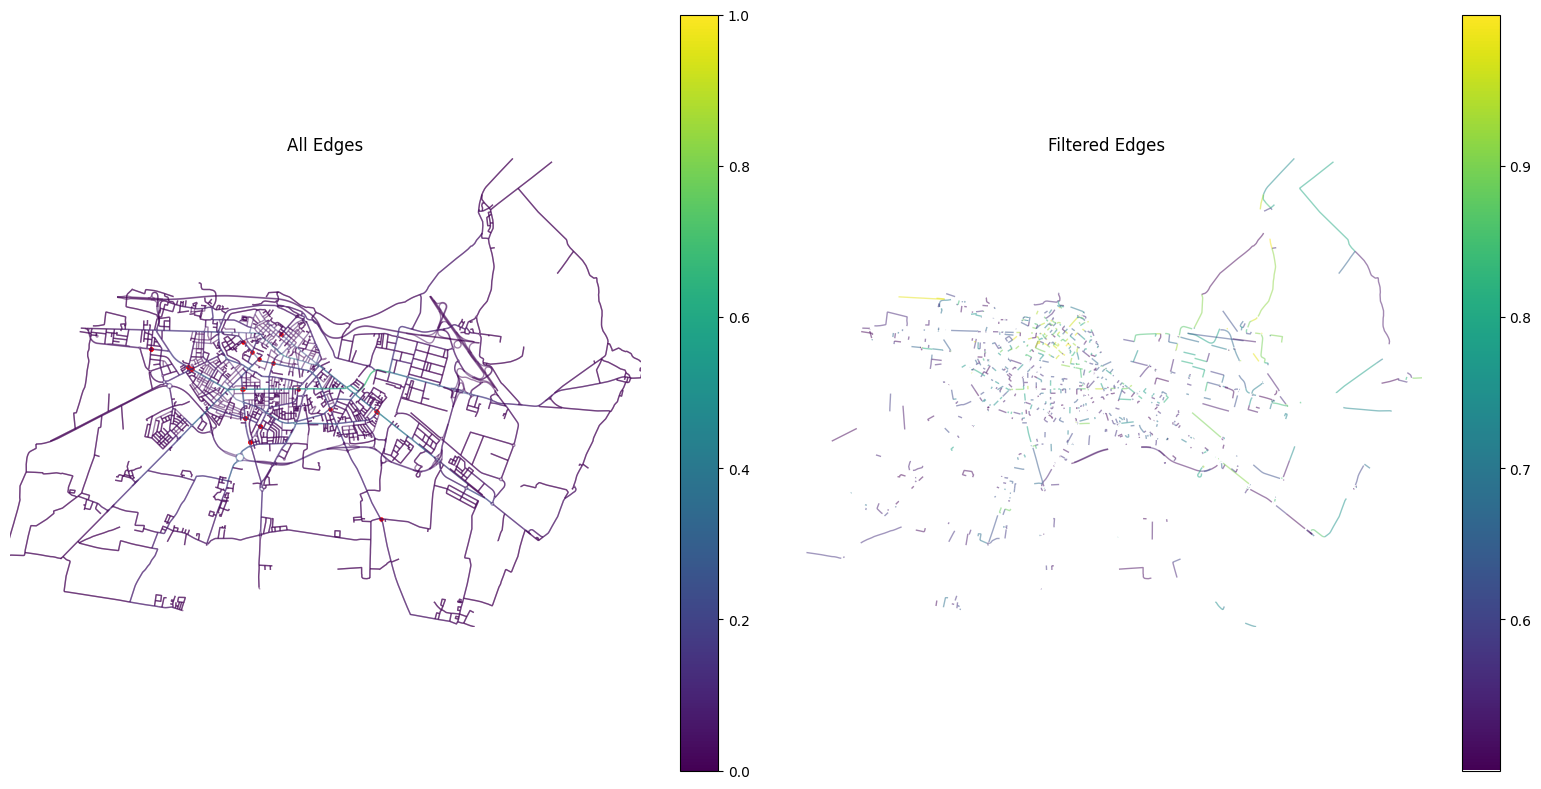

In [22]:
edges_gnn_filtered = edges_gnn.merge(filtered_edges_osmid, on=['u', 'v'], how='inner')
print(f"Number of filtered edges: {len(edges_gnn_filtered)}")
# assign attention weights to the filtered edges
edges_gnn_filtered['Attention Score'] = filtered_edges_osmid['Attention Score']
# Visualization of filtered edges vs all edges
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot all edges
edges_gnn.plot(ax=ax1, linewidth=1, alpha=0.5, column = 'edge_bc', cmap='viridis', legend=True)
nodes_gnn[nodes_gnn['traffic_lights'] == 1].plot(ax=ax1, color='red', markersize=5)
ax1.set_title('All Edges')
ax1.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax1.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax1.set_axis_off()

# Plot filtered edges
edges_gnn_filtered.plot(ax=ax2, linewidth=1, alpha=0.5, column='Attention Score', cmap='viridis', legend=True)
ax2.set_title('Filtered Edges')
ax2.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax2.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax2.set_axis_off()

plt.tight_layout()
plt.show()

we can see from this inspection that the GAT learns to focus on betweeness centrality, presence of traffic lights, and learns that the highway is faster (in first layer maybe).

I think this is promising, we will also compare with a completely new dataset, and we will see if the attention weights are still similar. but for now let's move to the transformer model.

## Graph Transformer
### let's start with the one layer MultiheadAttention.

In [6]:
# Preprocess the data and prepare the dataset
transform = T.AddRandomWalkPE( walk_length= 20, attr_name= 'pe')
transform2 = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
data = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(Y), edge_index = edge_index )
data = transform2(data)

# Split data into train/val/test sets (70%/15%/15%)
np.random.seed(10)        
n_edges = data.num_edges
indices = np.random.permutation(n_edges)
        
train_idx = indices[:int(0.7 * n_edges)]
print(len(train_idx)) #debug
val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
print(len(val_idx)) #debug
test_idx = indices[int(0.85 * n_edges):]
print(len(test_idx)) #debug
        
# Create masks
train_mask = torch.zeros(n_edges, dtype=torch.bool)
val_mask = torch.zeros(n_edges, dtype=torch.bool)
test_mask = torch.zeros(n_edges, dtype=torch.bool)
    
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
        
data.train_mask = train_mask    #size is still all nodes but only True for train nodes
data.val_mask = val_mask
data.test_mask = test_mask

data.to(device)

4851
1039
1040


Data(x=[3231, 6], edge_index=[2, 6930], y=[6930], pe=[3231, 20], train_mask=[6930], val_mask=[6930], test_mask=[6930])

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define hyperparameters
HIDDEN_DIM = 64
LR = 0.01
EPOCHS = 1000


class GraphTransformer(nn.Module):
    """
    A Transformer-based model for graph data processing.
    """
    def __init__(
        self,
        in_channels: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        dropout: float = 0.4,
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)


        # Attention block with normalization
        self.norm1 = nn.LayerNorm(hidden_channels)
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_channels,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Feed-forward block
        self.mlp = Sequential(
            Linear(2* hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, 1)
            
        )
        
    
    def forward(self, x, pe, edge_index ,mask = None):
        
        # Input embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Attention block with residual connection
        residual = x
        x = self.norm1(x)
        
        x = x.unsqueeze(0)

        attn_mask = None

        # Apply self-attention (q,k,v are all the same in self-attention)
        attn_output, attn_weights = self.attention(
            query=x,
            key=x,
            value=x,
            attn_mask = attn_mask,
            need_weights= True,
            average_attn_weights=False,
        )
        x = attn_output.squeeze(0) + residual

        # Feed-forward block
        src, dst = edge_index
        x = torch.cat((x[src], x[dst]), dim=1)  # [num_edges, 2*hidden_channels]
        x = self.mlp(x)         # [num_edges, 1]
        return x, attn_weights
    
# Initialise model instance
model = GraphTransformer(
    in_channels=data.x.shape[1],
    pe_dim=8,
    hidden_channels=HIDDEN_DIM,
    heads=4,
    dropout=0.5
).to(device)
model

GraphTransformer(
  (node_emb): Linear(in_features=6, out_features=56, bias=True)
  (pe_lin): Linear(in_features=20, out_features=8, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [13]:
# Extract attention weights
_, attn_weights = model(data.x, data.pe, data.edge_index)
attn_weights = attn_weights.cpu().detach().numpy().squeeze()
attn_weights.shape

(4, 3231, 3231)

This is the only case where we have classical node to node attention.

In this section I will try to inspect and study them.

<Axes: >

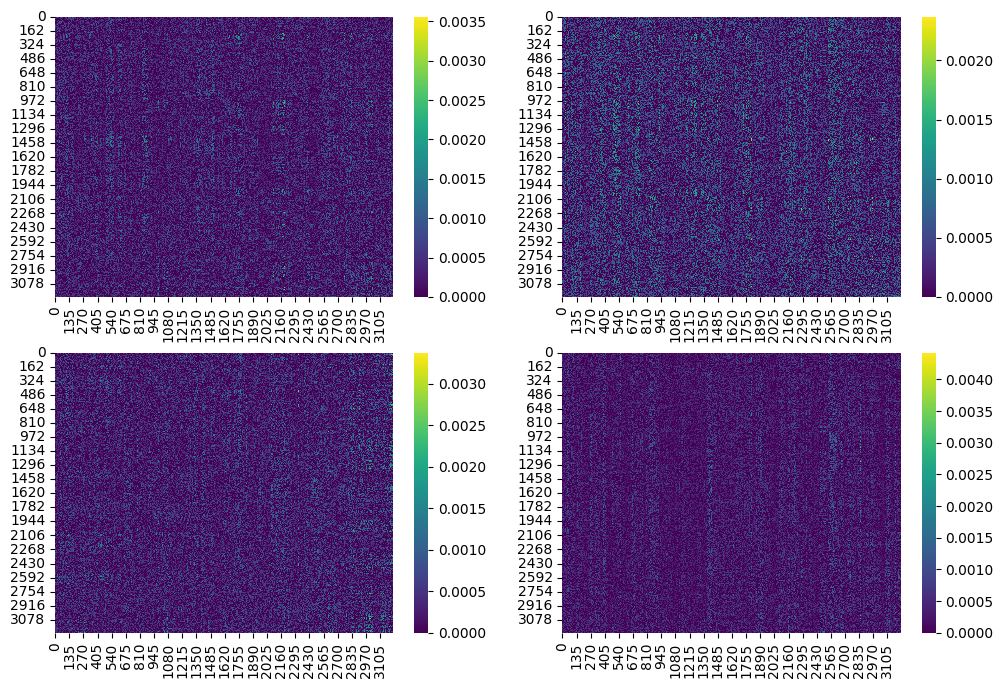

In [19]:
import seaborn as sns
# let's plot the 4 attention heads as heatmaps
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2, ax3, ax4 = axs.flatten()
sns.heatmap(attn_weights[0], ax=ax1, cmap='viridis')
sns.heatmap(attn_weights[1], ax=ax2, cmap='viridis')
sns.heatmap(attn_weights[2], ax=ax3, cmap='viridis')
sns.heatmap(attn_weights[3], ax=ax4, cmap='viridis')

In [127]:
# Select a specific attention head to analyze
head_idx = 3  # Change to analyze different heads

# Get attention weights for the selected head
head_attn = attn_weights[head_idx]  # Shape: [3231, 3231]

# Define how many top pairs to select
top_k = 100  # Adjust as needed

# Flatten the attention matrix and find top-k indices
flattened_attn = head_attn.flatten()
top_k_flat_indices = np.argsort(flattened_attn)[-top_k:][::-1]  # Get indices of top-k values

# Convert flat indices back to 2D indices (source, target)
num_nodes = head_attn.shape[0]
source_nodes = top_k_flat_indices // num_nodes
target_nodes = top_k_flat_indices % num_nodes
attn_values = flattened_attn[top_k_flat_indices]

# Create list of (source, target, attention) tuples
high_attention_pairs = list(zip(source_nodes, target_nodes, attn_values))

# Print statistics and top pairs
print(f"Top {top_k} attention pairs for head {head_idx}:")
print(f"Attention range: {attn_values.min():.4f} to {attn_values.max():.4f}")

for idx, (i, j, att) in enumerate(high_attention_pairs[:10]):  # Show first 10
    print(f"{idx+1}. Source node {i} → Target node {j}: Attention = {att:.4f}")

# Create a list of all nodes involved in the attention pairs
all_nodes = list(set(source_nodes) | set(target_nodes))
# Create a GeoDataFrame for the selected nodes
selected_nodes = nodes_gnn.iloc[all_nodes].copy()
# Remove duplicates
selected_nodes = selected_nodes.drop_duplicates()

# Create edge geometries for visualization
edge_geometries = []
edge_attrs = []  # To store attributes

# Create LineString geometries for each pair
for i, j, att in high_attention_pairs:
    source_point = nodes_gnn.iloc[i].geometry
    target_point = nodes_gnn.iloc[j].geometry
    
    # Create a LineString between the two points
    line = LineString([source_point, target_point])
    
    # Store geometry and attributes
    edge_geometries.append(line)
    edge_attrs.append({'source': int(i), 'target': int(j), 'attention': float(att)})

# Create a GeoDataFrame with attributes
high_attention_edges = gpd.GeoDataFrame(edge_attrs, geometry=edge_geometries, crs=nodes_gnn.crs)

Top 100 attention pairs for head 3:
Attention range: 0.0034 to 0.0044
1. Source node 1011 → Target node 2621: Attention = 0.0044
2. Source node 1011 → Target node 2622: Attention = 0.0044
3. Source node 1011 → Target node 2848: Attention = 0.0042
4. Source node 1011 → Target node 2615: Attention = 0.0041
5. Source node 818 → Target node 2620: Attention = 0.0041
6. Source node 3048 → Target node 2620: Attention = 0.0041
7. Source node 1155 → Target node 2622: Attention = 0.0041
8. Source node 1155 → Target node 2613: Attention = 0.0040
9. Source node 567 → Target node 2620: Attention = 0.0040
10. Source node 1011 → Target node 2623: Attention = 0.0040


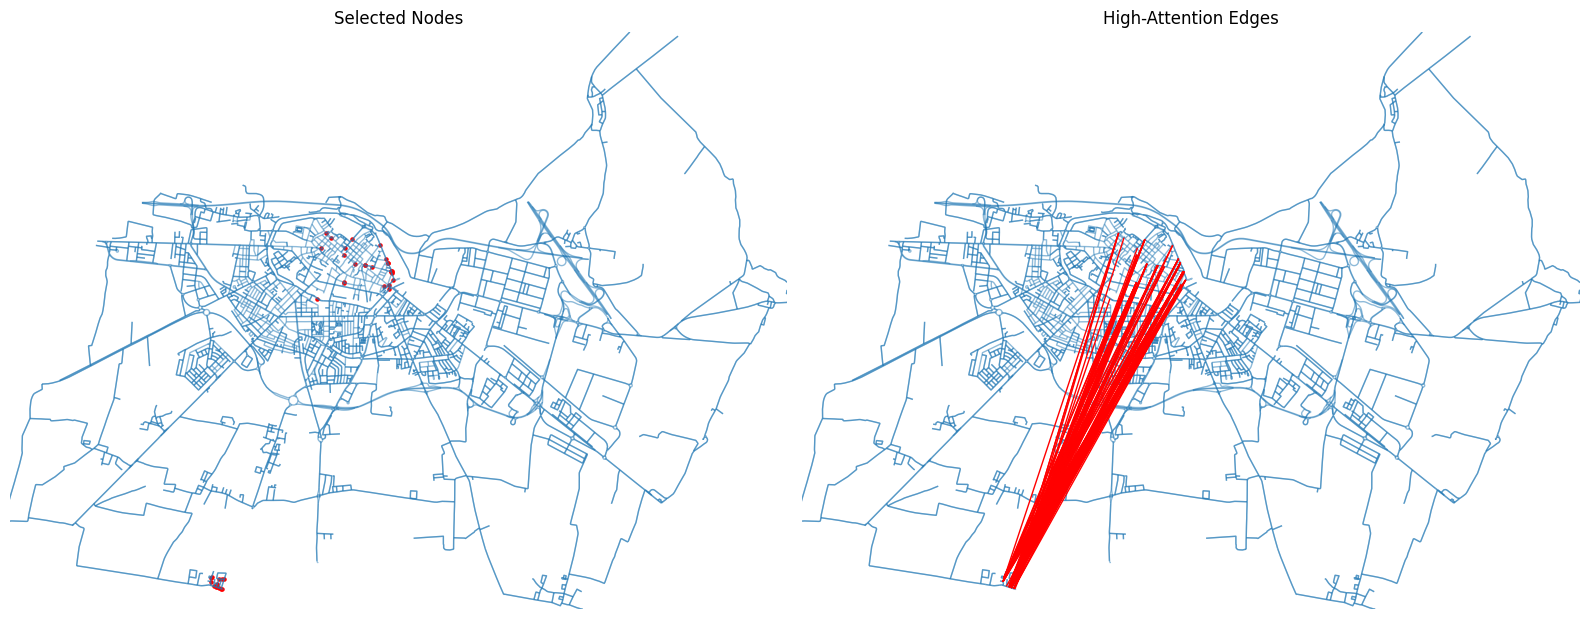

In [135]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot selected nodes
edges_gnn.plot(ax=ax1, linewidth=1, alpha=0.5)
selected_nodes.plot(ax=ax1, color='red', markersize=5)
ax1.set_title('Selected Nodes')
ax1.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax1.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax1.set_axis_off()

# Plot all edges
edges_gnn.plot(ax=ax2, linewidth=1, alpha=0.5)
# Plot high-attention edges
high_attention_edges.plot(ax=ax2, color='red', linewidth=1)
ax2.set_title('High-Attention Edges')
ax2.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax2.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax2.set_axis_off()

plt.tight_layout()
plt.show()

As the head changes we can see that each head top k attention weights are on completely different nodes and different parts of the graph.

### Performer time
Let's look into the performer attention now, even though it won't be a full attention matrix

In [141]:
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.nn.attention.performer import generalized_kernel
import torch.nn.functional as F

# Define hyperparameters
HIDDEN_DIM = 64

class GraphPerformer(nn.Module):
    """
    A Performer-based model for graph data processing.
    """
    def __init__(
        self,
        in_channels: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        dropout: float = 0.4,
        
    ):
        super().__init__()
        
        # Input embedding

        self.node_emb = Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)

        #self.input_proj = nn.Linear(in_channels, hidden_channels)
        
        # Attention block with normalization
        self.norm1 = nn.LayerNorm(hidden_channels)
        self.attention = PerformerAttention(
            channels=hidden_channels,
            heads=heads,
            head_channels=head_channels,
            dropout=dropout
        )
        
        # Feed-forward block
        self.mlp = Sequential(
            Linear(2* hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, 1)
            
        )
    
    def forward(self, x, pe, edge_index ,mask = None):
        
        # Input embedding
        x_pe = self.pe_norm(pe)
        #print(f"x_pe: {x_pe.shape}")
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        #print(f"x: {x.shape}")
        #x = self.input_proj(x)
        
        # Attention block with residual connection
        residual = x
        x = self.norm1(x)
        #print(f"x: {x.shape}")
        x = x.unsqueeze(0)
        x = residual + self.attention(x, mask=mask)
        x = x.squeeze(0)
        #print(f"x: {x.shape}")
        
        # Feed-forward block 

        src, dst = edge_index
        x = torch.cat((x[src], x[dst]), dim=1)
        x = self.mlp(x)
        
                
        return x
    
    def get_performer_attention(self, x, pe, edge_index):
        """Extract the attention approximation used by Performer."""
        self.eval()
        with torch.no_grad():
            # Get node embeddings
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Add batch dimension
            x = x.unsqueeze(0)
            
            # Get Q, K, V projections
            B, N, _ = x.shape
            q, k, v = self.attention.q(x), self.attention.k(x), self.attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, self.attention.heads, self.attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            
            # Apply the kernel approximation to q and k
            fast_attn = self.attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
                
            # Compute approximate attention matrix -- This is analogous to softmax in standard attention
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)  # Sum over nodes

            attention_weights = []
            for h in range(self.attention.heads):
                head_q = q_prime[0, h]  # [N, features]
                head_k = k_prime[0, h]  # [N, features]
            
                # Compute normalized attention (shape: [N, N])
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]  # [1, features]
                    # Normalized kernel dot product for each node pair
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            return torch.stack(attention_weights)
    
    @torch.no_grad()
    def redraw_projection_matrix(self):
        """Redraws the random projection matrix to improve approximation."""
        self.attention.redraw_projection_matrix()

# Initialise model and load trained weights
model = GraphPerformer(
    in_channels=data.x.shape[1],
    pe_dim=8,
    hidden_channels=HIDDEN_DIM,
    heads=4,
    head_channels=16,
    dropout=0.5
).to(device)
model.load_state_dict(torch.load('best_CR_performer.pt', map_location=device))

<All keys matched successfully>

In [161]:
# Get attention scores (shape: [heads, nodes, nodes])
attention_scores = model.get_performer_attention(
    data.x, data.pe, data.edge_index
)
attention_scores = attention_scores.squeeze(0)  # Remove batch dimension
attention_scores.shape

torch.Size([4, 3231, 3231])

Ok so let's try to explain what I did in this previous steps, since Performer uses kernel trick to avoid computing the full attention matrix we can still use the approximated key values and query to compute it manually. 
The result is an approximation of the real softmax attention matrix but it still give us the ability to interpret the attention weights.

The approximation works because:

1. Performer maps Q → φ(Q) and K → φ(K) using random feature projections
2. These mappings are designed so that φ(Q)φ(K)^T ≈ exp(QK^T/√d)
3. When properly normalized, this approximates softmax(QK^T/√d)

Remember that this is:

- Not identical to what a standard transformer would compute
- Slightly different from what Performer uses internally (as Performer never materializes this matrix)
- Still meaningful for interpretation and visualization purposes

In [157]:
from shapely.geometry import LineString

# Select a specific attention head to analyze (out of 4 heads)
head_idx = 3  # Change to analyze different heads
head_attn = attention_scores[head_idx].cpu().detach().numpy()  # Shape: [nodes, nodes]

# Define how many top pairs to select
top_k = 100  # Adjust as needed

# Flatten the attention matrix and find top-k indices
flattened_attn = head_attn.flatten()
top_k_flat_indices = np.argsort(flattened_attn)[-top_k:][::-1]  # Get indices of top-k values

# Convert flat indices back to 2D indices (source, target)
num_nodes = head_attn.shape[0]
source_nodes = top_k_flat_indices // num_nodes
target_nodes = top_k_flat_indices % num_nodes
attn_values = flattened_attn[top_k_flat_indices]

# Create list of (source, target, attention) tuples
high_attention_pairs = list(zip(source_nodes, target_nodes, attn_values))

# Print statistics and top pairs
print(f"Top {top_k} attention pairs for head {head_idx}:")
print(f"Attention range: {attn_values.min():.4f} to {attn_values.max():.4f}")

for idx, (i, j, att) in enumerate(high_attention_pairs[:10]):  # Show first 10
    print(f"{idx+1}. Source node {i} → Target node {j}: Attention = {att:.4f}")

# Create a list of all nodes involved in the attention pairs
all_nodes = list(set(source_nodes) | set(target_nodes))
# Create a GeoDataFrame for the selected nodes
selected_nodes = nodes_gnn.iloc[all_nodes].copy()
# Remove duplicates
selected_nodes = selected_nodes.drop_duplicates()

Top 100 attention pairs for head 3:
Attention range: 0.0060 to 0.0090
1. Source node 126 → Target node 127: Attention = 0.0090
2. Source node 492 → Target node 127: Attention = 0.0088
3. Source node 128 → Target node 127: Attention = 0.0087
4. Source node 1102 → Target node 127: Attention = 0.0086
5. Source node 1669 → Target node 127: Attention = 0.0080
6. Source node 501 → Target node 127: Attention = 0.0079
7. Source node 130 → Target node 127: Attention = 0.0079
8. Source node 2179 → Target node 127: Attention = 0.0078
9. Source node 1707 → Target node 127: Attention = 0.0078
10. Source node 124 → Target node 127: Attention = 0.0078


In [158]:
# Create edge geometries for visualization
edge_geometries = []
edge_attrs = []  # To store attributes

# Create LineString geometries for each pair
for i, j, att in high_attention_pairs:
    source_point = nodes_gnn.iloc[i].geometry
    target_point = nodes_gnn.iloc[j].geometry
    
    # Create a LineString between the two points
    line = LineString([source_point, target_point])
    
    # Store geometry and attributes
    edge_geometries.append(line)
    edge_attrs.append({'source': int(i), 'target': int(j), 'attention': float(att)})

# Create a GeoDataFrame with attributes
high_attention_edges = gpd.GeoDataFrame(edge_attrs, geometry=edge_geometries, crs=nodes_gnn.crs)

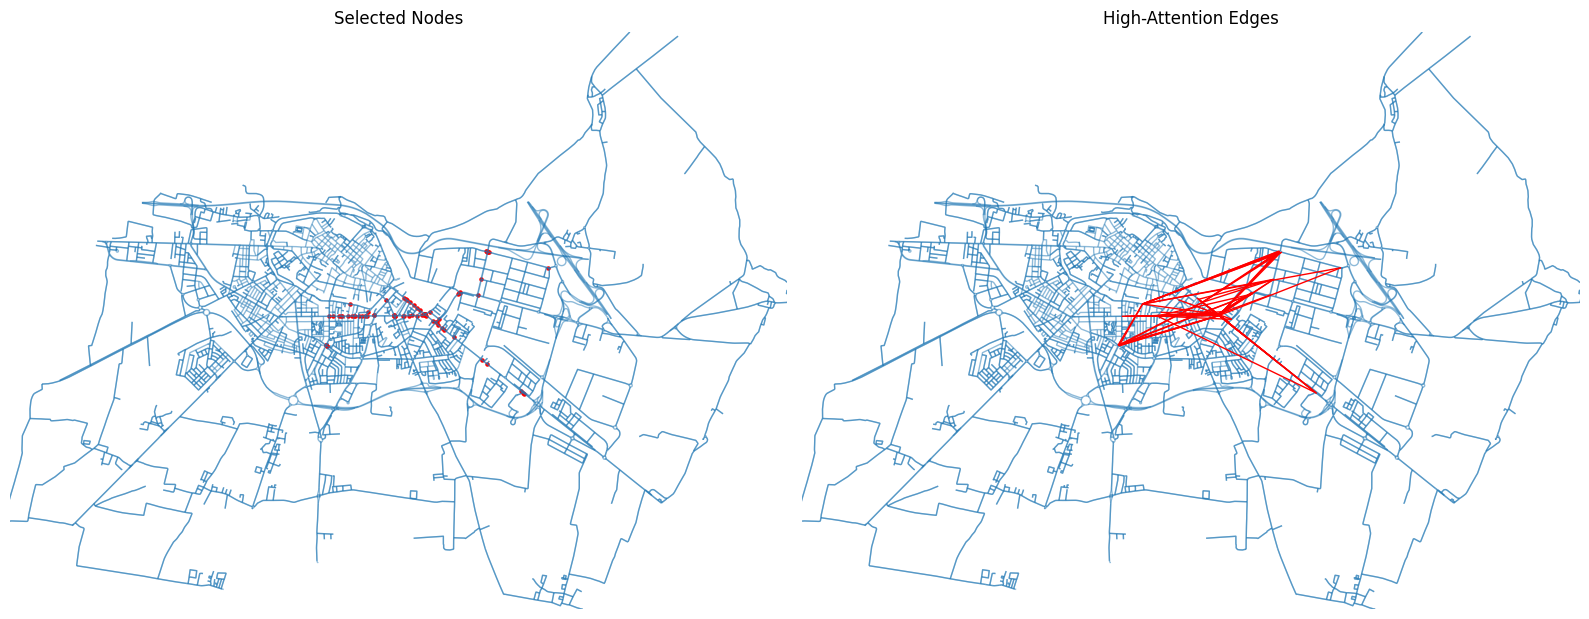

In [159]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# Plot selected nodes
edges_gnn.plot(ax=ax1, linewidth=1, alpha=0.5)
selected_nodes.plot(ax=ax1, color='red', markersize=5)
ax1.set_title('Selected Nodes')
ax1.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax1.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax1.set_axis_off()

# Plot all edges
edges_gnn.plot(ax=ax2, linewidth=1, alpha=0.5)
# Plot high-attention edges
high_attention_edges.plot(ax=ax2, color='red', linewidth=1)
ax2.set_title('High-Attention Edges')
ax2.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax2.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax2.set_axis_off()

plt.tight_layout()
plt.show()